# Proyecto final de "Introducción a la Inteligencia Artificial"
## Dataset sobre "Rendimiento y comportamiento de los estudiantes"
https://www.kaggle.com/datasets/mahmoudelhemaly/students-grading-dataset

Este conjunto de datos son datos reales de 5.000 registros recopilados de un proveedor privado de aprendizaje.
El conjunto de datos incluye atributos clave necesarios para explorar patrones, correlaciones y perspectivas relacionadas con el rendimiento académico.


## Objetivos del proyecto

El flujo de trabajo de este proyecto de ciencia de datos resuelve siete objetivos principales.

* __Clasificación__. Es posible que deseemos clasificar o categorizar nuestras muestras. También es posible que deseemos comprender las implicaciones o la correlación de diferentes clases con nuestro objetivo.

* __Correlación__. Se puede abordar el problema en función de las características disponibles dentro del conjunto de datos de entrenamiento. ¿Qué características dentro del conjunto de datos contribuyen significativamente a nuestro objetivo de solución? Hablando estadísticamente, ¿existe una correlación entre una característica y el objetivo de la solución? A medida que cambian los valores de las funciones, ¿cambia también el estado de la solución y viceversa? Esto se puede probar tanto para características numéricas como categóricas en el conjunto de datos dado. También es posible que deseemos determinar la correlación entre características distintas de la supervivencia para los objetivos posteriores y las etapas del flujo de trabajo. Correlacionar ciertas características puede ayudar a crear, completar o corregir características.

* __Conversión__. Para la etapa de modelado, es necesario preparar los datos. Dependiendo de la elección del modelo de algoritmo, se puede requerir que todas las características se conviertan a valores numéricos equivalentes. Por ejemplo, convertir valores categóricos de texto en valores numéricos.
Completado. La preparación de datos también puede requerir que estimemos los valores faltantes dentro de una característica. Los algoritmos de modelado pueden funcionar mejor cuando no faltan valores.

* __Corrección__. También podemos analizar el conjunto de datos de entrenamiento dado en busca de errores o posibles valores inexactos dentro de las características e intentar corregir estos valores o excluir las muestras que contienen los errores. Una forma de hacerlo es detectar cualquier valor atípico entre nuestras muestras o características. También podemos descartar completamente una característica si no contribuye al análisis o puede sesgar significativamente los resultados.

* __Creación__. ¿Podemos crear nuevas características basadas en una característica existente o un conjunto de características, de modo que la nueva característica siga los objetivos de correlación, conversión e integridad?
Gráficos. Cómo seleccionar los gráficos y diagramas de visualización correctos según la naturaleza de los datos y los objetivos de la solución.

* __Gráficos.__ Cómo seleccionar los gráficos y diagramas de visualización correctos según la naturaleza de los datos y los objetivos de la solución.

## Imports

In [1]:
#pip install sklearn
#pip install pandas
#pip install numpy
#pip install random
#pip install seaborn
#pip install matplotlib

Línea para poder utilizar el Google Colab

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Explicación:

pandas (pd): Se utiliza para la manipulación y análisis de datos, lo que nos permite manejar conjuntos de datos estructurados.

numpy (np): Proporciona soporte para operaciones matemáticas y manejo de matrices numéricas.

matplotlib.pyplot (plt): Esencial para crear visualizaciones estáticas.

seaborn (sns): Construido sobre matplotlib, utilizado para gráficos estadísticos avanzados y estéticamente agradables.

warnings.filterwarnings("ignore"): Suprime los mensajes de advertencia para mejorar la legibilidad del cuaderno.

In [3]:
# Importamos las herremientas necesarias

# Análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
# La siguiente instrucción permite incorporar las gráficas en este documento (sin que se abra una nueva ventana para cada gráfico)
%matplotlib inline

# Entrenamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

# Línea para poder utilizar el Google Colab
import os

###############
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## Cargar datos

In [4]:
# Importamos el archivo "Students_Grading_Dataset.csv" desde la carpeta del Drive donde está y lo visualizamos en pantalla.
ruta = os.path.join('/content', 'drive', 'MyDrive', 'Colab Notebooks', 'Students_Grading_Dataset.csv')
df = pd.read_csv(ruta, delimiter = ",")
df

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,S5995,Ahmed,Jones,student4995@university.com,Male,19,Business,NaN,82.15,60.33,...,58.42,85.21,D,25.5,No,Yes,High School,Low,10,8.3
4996,S5996,Emma,Brown,student4996@university.com,Male,19,Business,65.11,86.31,49.80,...,60.87,95.96,C,5.0,No,Yes,NaN,Medium,4,4.0
4997,S5997,John,Brown,student4997@university.com,Female,24,CS,87.54,63.55,64.21,...,82.65,54.25,A,24.8,Yes,No,High School,Medium,4,6.3
4998,S5998,Sara,Davis,student4998@university.com,Male,23,CS,92.56,79.79,94.28,...,94.29,55.84,A,16.1,Yes,Yes,Bachelor's,Low,1,8.4


## Analisis de los datos

In [5]:
# Mostramos el tamaño de nuestro DF: nº de filas y nº de columnas.
print("Número de filas:", len(df))
print("Número de columnas:", len(df.columns))

Número de filas: 5000
Número de columnas: 23


In [6]:
# Exploramos las columnas y los valores de nuestro DF.
print(df.columns)
print(df.values)

Index(['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Gender', 'Age',
       'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score',
       'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
       'Projects_Score', 'Total_Score', 'Grade', 'Study_Hours_per_Week',
       'Extracurricular_Activities', 'Internet_Access_at_Home',
       'Parent_Education_Level', 'Family_Income_Level', 'Stress_Level (1-10)',
       'Sleep_Hours_per_Night'],
      dtype='object')
[['S1000' 'Omar' 'Williams' ... 'Medium' 5 4.7]
 ['S1001' 'Maria' 'Brown' ... 'Medium' 4 9.0]
 ['S1002' 'Ahmed' 'Jones' ... 'Low' 6 6.2]
 ...
 ['S5997' 'John' 'Brown' ... 'Medium' 4 6.3]
 ['S5998' 'Sara' 'Davis' ... 'Low' 1 8.4]
 ['S5999' 'Maria' 'Brown' ... 'Low' 2 6.1]]


### Descripción de los datos

**Columnas:**

1. Student_ID: Identificador único para cada estudiante.
2. First_Name: Nombre del alumno.
3. Last_Name: Apellido del alumno.
4. Email: Correo electrónico de contacto (puede ser anónimo).
5. Gender: Masculino, Femenino, Otro.
6. Age: Edad del estudiante.
7. Department: Departamento del alumno (por ejemplo, CS, Ingeniería, Empresariales).
8. Attendance (%): Porcentaje de asistencia (0-100%).
9. Midterm_Score: Puntuación del examen parcial (sobre 100).
10. Final_Score: Puntuación del examen final (sobre 100).
11. Assignments_Avg: Puntuación media de todas las tareas (sobre 100).
12. Quizzes_Avg: Puntuación media de los quizzes (sobre 100).
13. Participation_Score: Puntuación basada en la participación en clase (0-10).
14. Projects_Score: Puntuación de la evaluación del proyecto (sobre 100).
15. Total_Score: Suma ponderada de todas las calificaciones.
16. Grade: Letra de calificación (A, B, C, D, F).
17. Study_Hours_per_Week: Promedio de horas de estudio por semana.
18. Extracurricular_Activities: Si el alumno participa en actividades extraescolares (Sí/No).
19. Internet_Access_at_Home: ¿El alumno tiene acceso a Internet en casa? (Sí/No).
20. Parent_Education_Level: Nivel educativo más alto de los padres (Ninguno, Secundaria, Licenciatura, Máster, Doctorado).
21. Family_Income_Level: Bajo, Medio, Alto.
22. Stress_Level (1-10): Nivel de estrés autodeclarado (1: bajo, 10: alto).
23. Sleep_Hours_per_Night: Media de horas de sueño por noche.

**El conjunto de datos contiene:**

* Valores perdidos (nulos): en algunos registros (por ejemplo, Attendance, Assignments o Parent_Education_Level).
* Sesgo en las calificaciones (por ejemplo, los alumnos con alta asistencia obtienen calificaciones ligeramente mejores).
* Distribuciones desequilibradas (por ejemplo, algunos departamentos tienen más alumnos).

### Clasificación y características de los datos.

**Categóricos:**

*   **Cardinales**

      Family_Income_Level (Low, Medium, Hight)

      Grade (A, B, C, D, F)

*   **Nominales**

    First_Name

    Last_Name

    Email

    Gender

    Department

    Extracurricular_Activities

    Internet_Access_at_Home

    Parent_Education_Level

**Numéricos:**

*   **Discretos**

    Age

    Stress_Level (1-10)

*   **Continuos**

    Attendance (%)

    Midterm_Score

    Final_Score

    Assignments_Avg

    Quizzes_Avg

    Participation_Score

    Projects_Score

    Total_Score

    Study_Hours_per_Week

    Sleep_Hours_per_Night

Código trabajado: [Students Analysis](https://www.kaggle.com/code/maryemahmed22/students-analysis)

In [7]:
# Comprobación de valores duplicados.
print(f'Valores duplicados: {df.duplicated().sum()}')

Valores duplicados: 0


In [8]:
# Presentamos la información general del DF
# La función info() proporciona una visión general del conjunto de datos, incluidos los tipos de datos y los valores faltantes.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   First_Name                  5000 non-null   object 
 2   Last_Name                   5000 non-null   object 
 3   Email                       5000 non-null   object 
 4   Gender                      5000 non-null   object 
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   object 
 7   Attendance (%)              4484 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             4483 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score              5000 

### Comprobación de valores que faltan por columnas

In [9]:
# Comprobación de valores que faltan por columnas
print("Valores que faltan en cada columna:")
df.isnull().sum()

Valores que faltan en cada columna:


,0
Student_ID,0
First_Name,0
Last_Name,0
Email,0
Gender,0
Age,0
Department,0
Attendance (%),516
Midterm_Score,0
Final_Score,0


### Porcentaje de datos que faltan en cada columna

In [10]:
# Porcentaje de datos que faltan en cada columna
print("Porcentaje de datos que faltan en cada columna:")
(df.isna().sum()/len(df)) * 100

Porcentaje de datos que faltan en cada columna:


,0
Student_ID,0.00
First_Name,0.00
Last_Name,0.00
Email,0.00
Gender,0.00
Age,0.00
Department,0.00
Attendance (%),10.32
Midterm_Score,0.00
Final_Score,0.00


**¿Qué características contienen valores en blanco, nulos o vacíos?**

Ciertos valores requerirán corrección como:
 - Attendance (%) (Porcentaje de asistencia (0-100%)): le faltan un 10,32 % de valores. Es interesante recuperarlo para ver su relación con los resultados obtenidos por los alumnos.
 - Assignments_Avg (Puntuación media de todas las tareas (sobre 100)):le faltan un 10,34 % de valores. Es interesante recuperarlo para ver su relación con los resultados obtenidos por los alumnos.
 - Parent_Education_Level (Nivel educativo más alto de los padres): Faltan el 35,88 % de los valores de esta característica. Sería interesante recuperarla para ver la relación entre el nivel de formación de los padres y los resultados académcos, pero el tanto por ciento de valores perdidos es elevado, así que lo estudiaremos.

In [11]:
# Generamos una tabla con las estadísticas de los campos numéricos.
numerical_stats = df.describe()
numerical_stats

,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night
count,5000.000000,4484.000000,5000.000000,5000.000000,4483.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,21.048400,75.431409,70.326844,69.640788,74.798673,74.910728,4.980024,74.924860,75.121804,17.658860,5.48080,6.488140
std,1.989786,14.372446,17.213209,17.238744,14.411799,14.504281,2.890136,14.423415,14.399941,7.275864,2.86155,1.452283
min,18.000000,50.010000,40.000000,40.000000,50.000000,50.030000,0.000000,50.010000,50.020000,5.000000,1.00000,4.000000
25%,19.000000,63.265000,55.457500,54.667500,62.090000,62.490000,2.440000,62.320000,62.835000,11.400000,3.00000,5.200000
50%,21.000000,75.725000,70.510000,69.735000,74.810000,74.695000,4.955000,74.980000,75.395000,17.500000,5.00000,6.500000
75%,23.000000,87.472500,84.970000,84.500000,86.970000,87.630000,7.500000,87.367500,87.652500,24.100000,8.00000,7.700000
max,24.000000,100.000000,99.980000,99.980000,99.980000,99.960000,10.000000,100.000000,99.990000,30.000000,10.00000,9.000000


### Comentario sobre las variables numéricas

Explicación de los parámetros estadísticos...

In [12]:
# Mostramos las variables categóricas.
df.describe(include = 'O')

,Student_ID,First_Name,Last_Name,Email,Gender,Department,Grade,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,3206,5000
unique,5000,8,6,5000,2,4,5,2,2,4,3
top,S5999,Maria,Johnson,student4999@university.com,Male,CS,A,No,Yes,PhD,Low
freq,1,657,868,1,2551,2022,1495,3493,4485,820,1983


### Comentarios sobre las variables categóricas.

---



**Gender:** Tenemos sólo dos géneros: masculino y femenino. A la hora de normalizar este dato sólo necesitamos dos valores (0,1).

**Department:** Sólo existen cuatro casos posibles para departamento: Engineering, Business, Mathematics, CS. A la hora de normalizar esta columna, sólo necesitaremos cuatro valores (0, 1, 2, 3).

**Grade:** Corresponde a la calificación en formato literal (A, B, C, D, F). A la hora de normalizar este dato sólo necesitaremos 5 valores (0, 1, 2, 3, 4).

**Extracurricular_Activities:** Aquí sólo existen dos valores, sí o no. Para normalizar este dato sólo necesitamos dos valores (0, 1).

**Internet_Access_at_Home:** Aquí sólo existen dos valores, sí o no. Para normalizar este dato sólo necesitamos dos valores (0, 1).

**Parent_Education_Level:** Según el informe de las variables categóricas sólo hay cuatro datos. Habrá que hacer una consulta para saber cuales son sus valores y cómo normalizarlos. Aún así sólo necesitamos cuatro valores (0, 1, 2, 3).

**Family_Income_Level:** En el nivel de ingresos familiares sólo hay tres opciones: low, medium, hight; por lo que sólo necesitamos tres valores (0, 1, 2).

###Visualización de ciertas variables categóricas con más de dos valores posibles.

In [13]:
df['Department'].value_counts()

,count
Department,
CS,2022
Engineering,1469
Business,1006
Mathematics,503


In [14]:
df['Family_Income_Level'].value_counts()

,count
Family_Income_Level,
Low,1983
Medium,1973
High,1044


In [15]:
df['Grade'].value_counts()

,count
Grade,
A,1495
B,978
D,889
F,844
C,794


In [16]:
df['Parent_Education_Level'].unique()

array(['High School', nan, "Master's", 'PhD', "Bachelor's"], dtype=object)

In [17]:
df['Parent_Education_Level'].value_counts()

,count
Parent_Education_Level,
PhD,820
Bachelor's,810
High School,796
Master's,780


###Visión de la categoría "Gender" (género)

In [18]:
# Número de personas de género masculino
df_Male = df["Gender"][df["Gender"] == "Male"].count()
print(df_Male)

2551


In [19]:
# Número de personas de género femenino
df_Female = df["Gender"][df["Gender"] == "Female"].count()
print(df_Female)

2449


In [20]:
# Número de personas que no especifican su género
df_Otro = df["Gender"][df["Gender"] == "Otro"].count()
print(df_Otro)

0


<Axes: >

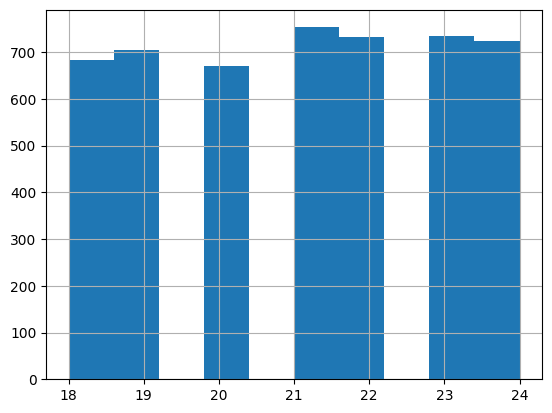

In [21]:
df['Age'].hist()

<Axes: >

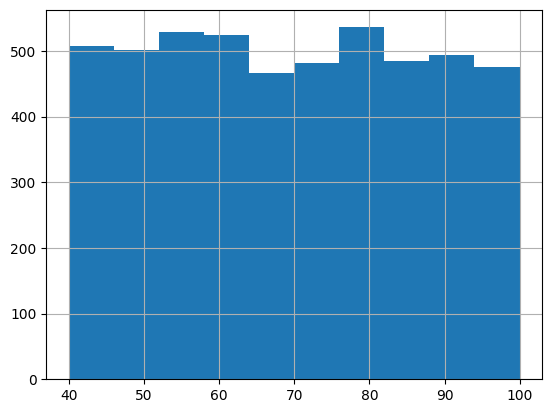

In [22]:
df['Final_Score'].hist()

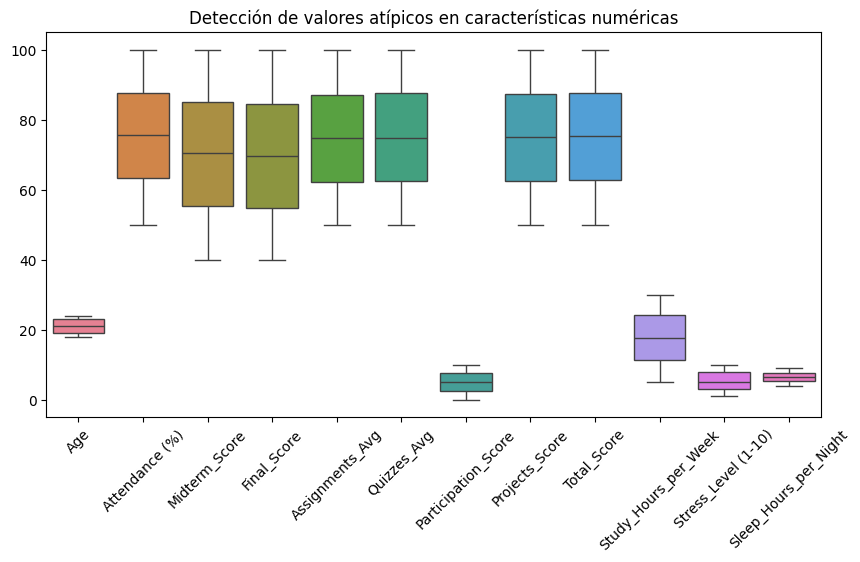

In [23]:
# Comprobación de valores atípicos en columnas numéricas
plt.figure(figsize=(10, 5))
sns.boxplot(data=df.select_dtypes(include=['number']))
plt.title("Detección de valores atípicos en características numéricas")
plt.xticks(rotation=45)
plt.show()

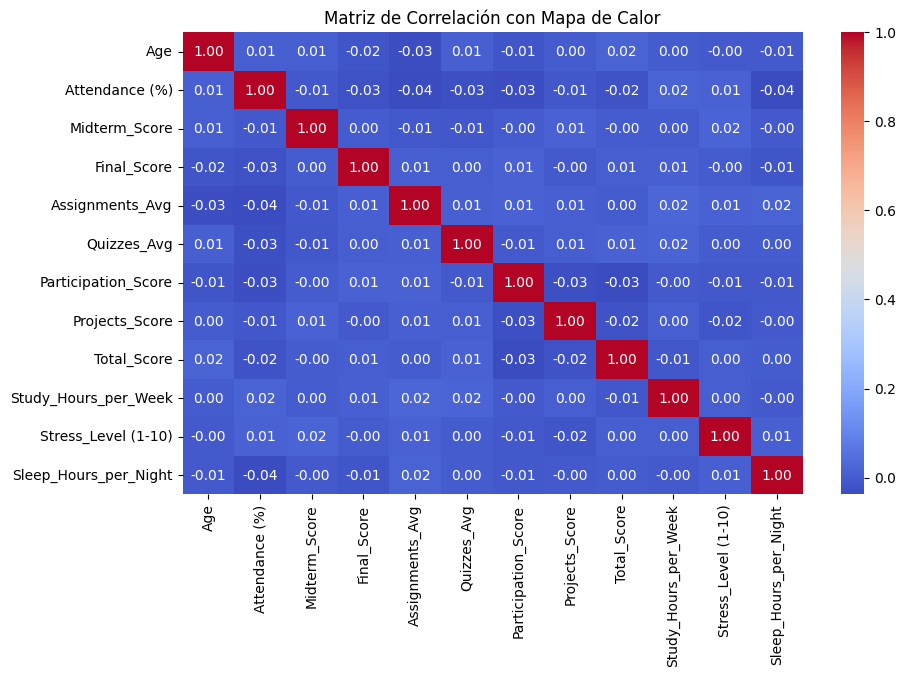

In [24]:
# Matriz de correlación con Mapa de Calor (sólo para las características numéricas)
plt.figure(figsize=(10, 6))
numerical_df = df.select_dtypes(include=['number'])  # Seleccionamos sólo las columnas numéricas
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriz de Correlación con Mapa de Calor")
plt.show()

In [25]:
df[['Study_Hours_per_Week', 'Total_Score']].groupby(['Study_Hours_per_Week'], as_index=False).mean().sort_values(by='Total_Score', ascending=False)

,Study_Hours_per_Week,Total_Score
48,9.8,83.772778
132,18.2,82.601818
196,24.6,82.433077
154,20.4,82.365217
191,24.1,81.777931
...,...,...
82,13.2,67.108750
173,22.3,66.730714
140,19.0,66.724706
239,28.9,66.438929


## Limpieza y Preprocesamiento de Datos
### Gestión de los valores que faltan.

Attendance (%) (Asistencia (%)): Los valores que faltan se rellenan utilizando la media de asistencia.

Assignments_Avg (Asignaciones_Avg):  Los valores que faltan se rellenan utilizando la mediana de asignaciones.

Parent_Education_Level: Los valores categóricos que faltan se rellenan con 'unknown'

In [26]:
# Gestión de los valores que faltan
df.fillna({
    'Attendance (%)': df['Attendance (%)'].mean(),  # Los valores que faltan se rellenan utilizando la media de Attendance (asistencia)
    'Assignments_Avg': df['Assignments_Avg'].median(),  # Los valores que faltan se rellenan utilizando la mediana de Assignments_Avg (asignaciones_avg)
    'Parent_Education_Level': "unknown"  # Los valores categóricos que faltan se rellenan con 'unknown'
}, inplace=True)
df.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,unknown,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


###Eliminar la columnas que no son relevantes.

In [27]:
df.drop(['Student_ID', 'First_Name','Last_Name','Email'], axis=1, inplace=True)
df.head()

,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,Female,22,Engineering,52.29,55.03,57.82,84.22,74.06,3.99,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,Male,18,Engineering,97.27,97.23,45.80,74.81,94.24,8.32,55.65,50.64,A,19.0,No,Yes,unknown,Medium,4,9.0
2,Male,24,Business,57.19,67.05,93.68,67.70,85.70,5.05,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,Female,24,Mathematics,95.15,47.79,80.63,66.06,93.51,6.54,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,Female,23,CS,54.18,46.59,78.89,96.85,83.70,5.97,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


In [28]:
# Vemos el número de columnas actulamente.
print("Número de columnas:", len(df.columns))

Número de columnas: 19


El actual número de columnas es de 19, ya que de las 23 iniciales hemos borrado 4 ('Student_ID',  'First_Name', 'Last_Name', 'Email').

Comenzamos a convertir los valores categóricos en numerales.

In [29]:
# Mapeando la categoría "Gender (género)"
gender_mapping = {"Female": 0, "Male": 1, "Otro": 2}
df['Gender'] = df['Gender'].map(gender_mapping)
df.head()

,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,0,22,Engineering,52.29,55.03,57.82,84.22,74.06,3.99,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,1,18,Engineering,97.27,97.23,45.80,74.81,94.24,8.32,55.65,50.64,A,19.0,No,Yes,unknown,Medium,4,9.0
2,1,24,Business,57.19,67.05,93.68,67.70,85.70,5.05,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,0,24,Mathematics,95.15,47.79,80.63,66.06,93.51,6.54,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,0,23,CS,54.18,46.59,78.89,96.85,83.70,5.97,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


In [30]:
# Mapeando la categoría "Department (departamento)"
department_mapping = {"Business": 0, "CS": 1, "Engineering": 2, "Mathematics": 3}
df['Department'] = df['Department'].map(department_mapping)
df.head()

,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,0,22,2,52.29,55.03,57.82,84.22,74.06,3.99,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,1,18,2,97.27,97.23,45.80,74.81,94.24,8.32,55.65,50.64,A,19.0,No,Yes,unknown,Medium,4,9.0
2,1,24,0,57.19,67.05,93.68,67.70,85.70,5.05,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,0,24,3,95.15,47.79,80.63,66.06,93.51,6.54,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,0,23,1,54.18,46.59,78.89,96.85,83.70,5.97,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


In [31]:
# Mapeando la categoría "Grade (calificación en formato literal)"
grade_mapping = {"F": 0, "D": 1, "C": 2, "B": 3 , "A": 4}
df['Grade'] = df['Grade'].map(grade_mapping)
df.head()

,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,0,22,2,52.29,55.03,57.82,84.22,74.06,3.99,85.90,56.09,0,6.2,No,Yes,High School,Medium,5,4.7
1,1,18,2,97.27,97.23,45.80,74.81,94.24,8.32,55.65,50.64,4,19.0,No,Yes,unknown,Medium,4,9.0
2,1,24,0,57.19,67.05,93.68,67.70,85.70,5.05,73.79,70.30,1,20.7,No,Yes,Master's,Low,6,6.2
3,0,24,3,95.15,47.79,80.63,66.06,93.51,6.54,92.12,61.63,4,24.8,Yes,Yes,High School,High,3,6.7
4,0,23,1,54.18,46.59,78.89,96.85,83.70,5.97,68.42,66.13,0,15.4,Yes,Yes,High School,High,2,7.1


In [32]:
# Mapeando la categoría "Extracurricular_Activities (actividades extraescolares)"
ext_act_mapping = {"No": 0, "Yes": 1}
df['Extracurricular_Activities'] = df['Extracurricular_Activities'].map(ext_act_mapping)
df.head()

,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,0,22,2,52.29,55.03,57.82,84.22,74.06,3.99,85.90,56.09,0,6.2,0,Yes,High School,Medium,5,4.7
1,1,18,2,97.27,97.23,45.80,74.81,94.24,8.32,55.65,50.64,4,19.0,0,Yes,unknown,Medium,4,9.0
2,1,24,0,57.19,67.05,93.68,67.70,85.70,5.05,73.79,70.30,1,20.7,0,Yes,Master's,Low,6,6.2
3,0,24,3,95.15,47.79,80.63,66.06,93.51,6.54,92.12,61.63,4,24.8,1,Yes,High School,High,3,6.7
4,0,23,1,54.18,46.59,78.89,96.85,83.70,5.97,68.42,66.13,0,15.4,1,Yes,High School,High,2,7.1


In [33]:
# Mapeando la categoría "Internet_Access_at_Home (Acceso a Internet en casa)"
int_acc_mapping = {"No": 0, "Yes": 1}
df['Internet_Access_at_Home'] = df['Internet_Access_at_Home'].map(int_acc_mapping)
df.head()

,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,0,22,2,52.29,55.03,57.82,84.22,74.06,3.99,85.90,56.09,0,6.2,0,1,High School,Medium,5,4.7
1,1,18,2,97.27,97.23,45.80,74.81,94.24,8.32,55.65,50.64,4,19.0,0,1,unknown,Medium,4,9.0
2,1,24,0,57.19,67.05,93.68,67.70,85.70,5.05,73.79,70.30,1,20.7,0,1,Master's,Low,6,6.2
3,0,24,3,95.15,47.79,80.63,66.06,93.51,6.54,92.12,61.63,4,24.8,1,1,High School,High,3,6.7
4,0,23,1,54.18,46.59,78.89,96.85,83.70,5.97,68.42,66.13,0,15.4,1,1,High School,High,2,7.1


In [34]:
# Mapeando la categoría "Parent_Education_Level (nivel educativo de los padres)"
par_edu_lev_mapping = {"unknown": 0, "Bachelor's": 1, "High School": 2, "Master's": 3 , "PhD": 4}
df['Parent_Education_Level'] = df['Parent_Education_Level'].map(par_edu_lev_mapping)
df.head()

,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,0,22,2,52.29,55.03,57.82,84.22,74.06,3.99,85.90,56.09,0,6.2,0,1,2,Medium,5,4.7
1,1,18,2,97.27,97.23,45.80,74.81,94.24,8.32,55.65,50.64,4,19.0,0,1,0,Medium,4,9.0
2,1,24,0,57.19,67.05,93.68,67.70,85.70,5.05,73.79,70.30,1,20.7,0,1,3,Low,6,6.2
3,0,24,3,95.15,47.79,80.63,66.06,93.51,6.54,92.12,61.63,4,24.8,1,1,2,High,3,6.7
4,0,23,1,54.18,46.59,78.89,96.85,83.70,5.97,68.42,66.13,0,15.4,1,1,2,High,2,7.1


In [35]:
# Mapeando la categoría "Family_Income_Level (nivel económico de la familia)"
fam_inc_lev_mapping = {"Low": 0, "Medium": 1, "High": 2}
df['Family_Income_Level'] = df['Family_Income_Level'].map(fam_inc_lev_mapping)
df.head()

,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,0,22,2,52.29,55.03,57.82,84.22,74.06,3.99,85.90,56.09,0,6.2,0,1,2,1,5,4.7
1,1,18,2,97.27,97.23,45.80,74.81,94.24,8.32,55.65,50.64,4,19.0,0,1,0,1,4,9.0
2,1,24,0,57.19,67.05,93.68,67.70,85.70,5.05,73.79,70.30,1,20.7,0,1,3,0,6,6.2
3,0,24,3,95.15,47.79,80.63,66.06,93.51,6.54,92.12,61.63,4,24.8,1,1,2,2,3,6.7
4,0,23,1,54.18,46.59,78.89,96.85,83.70,5.97,68.42,66.13,0,15.4,1,1,2,2,2,7.1


In [36]:
# Comprobamos el formato de todas las categorías.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gender                      5000 non-null   int64  
 1   Age                         5000 non-null   int64  
 2   Department                  5000 non-null   int64  
 3   Attendance (%)              5000 non-null   float64
 4   Midterm_Score               5000 non-null   float64
 5   Final_Score                 5000 non-null   float64
 6   Assignments_Avg             5000 non-null   float64
 7   Quizzes_Avg                 5000 non-null   float64
 8   Participation_Score         5000 non-null   float64
 9   Projects_Score              5000 non-null   float64
 10  Total_Score                 5000 non-null   float64
 11  Grade                       5000 non-null   int64  
 12  Study_Hours_per_Week        5000 non-null   float64
 13  Extracurricular_Activities  5000 

In [37]:
df.describe()

,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.00000,5000.000000
mean,0.510200,21.048400,1.293800,75.431409,70.326844,69.640788,74.799844,74.910728,4.980024,74.924860,75.121804,2.27820,17.658860,0.301400,0.897000,1.60440,0.812200,5.48080,6.488140
std,0.499946,1.989786,0.900691,13.610481,17.213209,17.238744,13.646227,14.504281,2.890136,14.423415,14.399941,1.47229,7.275864,0.458912,0.303989,1.50105,0.755146,2.86155,1.452283
min,0.000000,18.000000,0.000000,50.010000,40.000000,40.000000,50.000000,50.030000,0.000000,50.010000,50.020000,0.00000,5.000000,0.000000,0.000000,0.00000,0.000000,1.00000,4.000000
25%,0.000000,19.000000,1.000000,64.737500,55.457500,54.667500,63.687500,62.490000,2.440000,62.320000,62.835000,1.00000,11.400000,0.000000,1.000000,0.00000,0.000000,3.00000,5.200000
50%,1.000000,21.000000,1.000000,75.431409,70.510000,69.735000,74.810000,74.695000,4.955000,74.980000,75.395000,2.00000,17.500000,0.000000,1.000000,1.00000,1.000000,5.00000,6.500000
75%,1.000000,23.000000,2.000000,86.182500,84.970000,84.500000,85.570000,87.630000,7.500000,87.367500,87.652500,4.00000,24.100000,1.000000,1.000000,3.00000,1.000000,8.00000,7.700000
max,1.000000,24.000000,3.000000,100.000000,99.980000,99.980000,99.980000,99.960000,10.000000,100.000000,99.990000,4.00000,30.000000,1.000000,1.000000,4.00000,2.000000,10.00000,9.000000


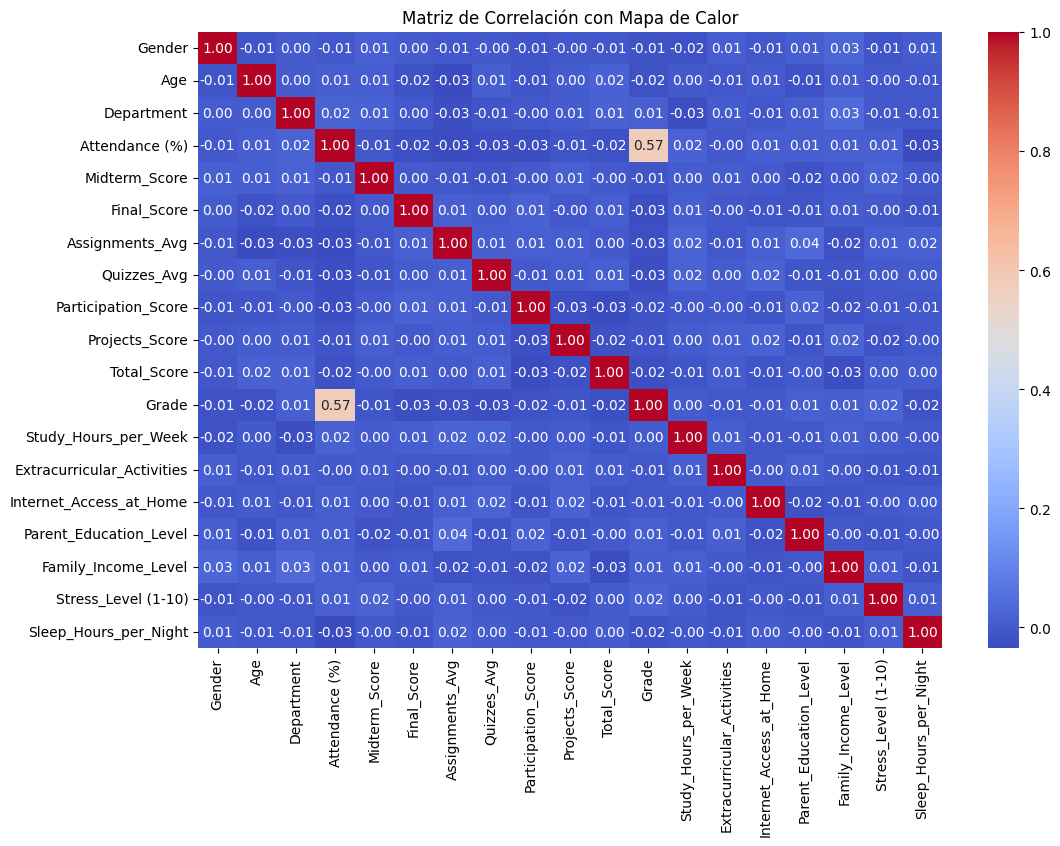

In [38]:
# Matriz de correlación con Mapa de Calor (todas las categorías)
plt.figure(figsize=(12, 8))
numerical_df = df.select_dtypes(include=['number'])  # Seleccionamos sólo las columnas numéricas
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriz de Correlación con Mapa de Calor")
plt.show()

## Entrenamiento
### Regresión lineal
En una primera aproximación relacionamos las siguientes categorías:

"Gender", "Age", "Department", "Attendance (%)", "Midterm_Score", "Assignments_Avg", "Quizzes_Avg", "Participation_Score", "Projects_Score", "Total_Score", "Study_Hours_per_Week", "Extracurricular_Activities", "Internet_Access_at_Home", "Parent_Education_Level", "Family_Income_Level", "Stress_Level (1-10)", "Sleep_Hours_per_Night"

Con la categoría:

'Final_Score'

para ver su relación.


In [39]:
x = df[["Gender", "Age", "Department", "Attendance (%)", "Midterm_Score", "Assignments_Avg", "Quizzes_Avg", "Participation_Score", "Projects_Score", "Total_Score", "Study_Hours_per_Week", "Extracurricular_Activities", "Internet_Access_at_Home", "Parent_Education_Level", "Family_Income_Level", "Stress_Level (1-10)", "Sleep_Hours_per_Night"]]
y = df['Final_Score']
print("Dataset cargado. Número de registros: {}".format(x.shape[0]))

# Dividimos en un 20% para test y 80% para train
X_train, X_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size = 0.2,
                                                    random_state=20)
print("Hay {} registros en el set de train y {} registros en el set de test".format(X_train.shape[0], X_test.shape[0]))

Dataset cargado. Número de registros: 5000
Hay 4000 registros en el set de train y 1000 registros en el set de test


In [40]:
# Definimos el modelo, en este caso un modelo muy basico de regresión lineal
regression = LinearRegression() # Crea una instancia del modelo de regresión lineal

# Entrenamos el modelo
regression.fit(X_train, y_train)

train_score = round(regression.score(X_train, y_train),4)
test_score = round(regression.score(X_test, y_test),4)
print("Train Accuracy:", train_score) # Ahora muestra el R^2 en lugar de la precisión
print("Test Accuracy:", test_score)  # Ahora muestra el R^2 en lugar de la precisión

Train Accuracy: 0.002
Test Accuracy: -0.0121


Según estos datos no existe relación entre las categorías del dataset y "Final_Score.

En una segunda aproximación relacionamos las siguientes categorías:

"Gender", "Age", "Department", "Attendance (%)", "Midterm_Score", "Assignments_Avg", "Quizzes_Avg", "Participation_Score", "Projects_Score", "Total_Score", "Study_Hours_per_Week", "Extracurricular_Activities", "Internet_Access_at_Home", "Parent_Education_Level", "Family_Income_Level", "Stress_Level (1-10)", "Sleep_Hours_per_Night"

Con la categoría:

'Grade'

para ver su relación.

In [41]:
x = df[["Gender", "Age", "Department", "Attendance (%)", "Midterm_Score", "Assignments_Avg", "Quizzes_Avg", "Participation_Score", "Projects_Score", "Total_Score", "Study_Hours_per_Week", "Extracurricular_Activities", "Internet_Access_at_Home", "Parent_Education_Level", "Family_Income_Level", "Stress_Level (1-10)", "Sleep_Hours_per_Night"]]
y = df['Grade']
print("Dataset cargado. Número de registros: {}".format(x.shape[0]))

# Dividimos en un 20% para test y 80% para train
X_train, X_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size = 0.2,
                                                    random_state=20)
print("Hay {} registros en el set de train y {} registros en el set de test".format(X_train.shape[0], X_test.shape[0]))

Dataset cargado. Número de registros: 5000
Hay 4000 registros en el set de train y 1000 registros en el set de test


In [42]:
# Definimos el modelo, en este caso un modelo muy basico de regresión lineal
regression = LinearRegression() # Crea una instancia del modelo de regresión lineal

# Entrenamos el modelo
regression.fit(X_train, y_train)

train_score = round(regression.score(X_train, y_train),4)
test_score = round(regression.score(X_test, y_test),4)
print("Train Accuracy:", train_score) # Ahora muestra el R^2 en lugar de la precisión
print("Test Accuracy:", test_score)  # Ahora muestra el R^2 en lugar de la precisión

Train Accuracy: 0.3322
Test Accuracy: 0.3189


In [43]:
tabla = pd.DataFrame({
        "Data": ["Train Accuracy", "Test Accuracy"],
        "Nº rows": [X_train.shape[0], X_test.shape[0]],
        "Score": [train_score, test_score]
    })
tabla

,Data,Nº rows,Score
0,Train Accuracy,4000,0.3322
1,Test Accuracy,1000,0.3189


### Desarrollo de la regresión lineal

In [44]:
# Lonear Regression
linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)
print(y_pred)

y_pred_classes = np.round(y_pred)
print(y_pred_classes)

# Calcula la matriz de confusión
confusion_mat = confusion_matrix(y_test, y_pred_classes)
print(" > Matriz de confusión:")
print(confusion_mat)

# Obtener el informe de clasificación
report = classification_report(y_test, y_pred_classes)
print(" > Reporte de clasificación:")
print(report)

# Calcula la precisión
accuracy = accuracy_score(y_test, y_pred_classes)
print(" > Accuracy:", accuracy)

# Calcula la precisión por clase (solo para clasificación multiclase)
precision = precision_score(y_test, y_pred_classes, average=None)
print(" > Precisión por clase:", precision)
# Calcula la precision promedio
precision = precision_score(y_test, y_pred_classes, average='macro')
print(" > Precisión promedio:", precision)

# Calcula el recall por clase (solo para clasificación multiclase)
recall = recall_score(y_test, y_pred_classes, average=None)
print(" > Recall por clase:", recall)
# Calcula el recall promedio
recall = recall_score(y_test, y_pred_classes, average='macro')
print(" > Recall promedio:", recall)

# Calcula la puntuación F1 por clase (solo para clasificación multiclase)
f1 = f1_score(y_test, y_pred_classes, average=None)
print(" > F1 Score por clase:", f1)
# Calcula la puntuacion F1 promedio
f1 = f1_score(y_test, y_pred_classes, average='macro')
print(" > F1 Score promedio:", f1)

######################################################################################################
# Guardamos una de las metricas (F1 Score) como metrica global para la comparativa final
metrica_lin = round(f1 * 100, 2)
print(" >>> Metrica final Linear Regression:", metrica_lin)
######################################################################################################

[1.68047199 1.59998041 2.304618   3.67161135 2.24384511 1.90089463
 1.81722975 1.65236542 0.86666939 1.06200771 2.14077062 1.14174031
 1.74839226 1.58064021 2.2539385  0.7437985  2.27605966 3.34088494
 3.25126639 2.33220786 1.80841939 3.45557618 3.37901042 2.21600289
 1.92090359 3.33871761 3.37236659 2.2898812  3.13306202 3.05290544
 2.54441825 1.54036049 1.71676399 3.5017806  0.84301046 1.35635831
 3.34342644 3.67042275 2.51852707 1.13240796 0.86369402 3.65403409
 2.2995999  1.05530376 2.09115835 0.89715692 3.69586206 2.28087393
 3.64044414 1.78708863 1.23031337 3.22057713 2.12916101 2.37496564
 2.8650359  3.2280141  1.9608215  1.52569931 1.44205843 2.54205492
 0.64624542 2.42904764 3.12845311 3.54601046 1.09429562 1.8163531
 2.61198543 2.80377821 2.58087106 2.34141827 2.77602007 3.65928235
 3.02611545 0.84585664 0.71440038 1.01294688 2.18215286 1.07418583
 1.91364684 2.29326863 2.67240008 0.76444875 2.21975906 2.21490981
 2.07174705 0.83980026 2.330231   2.33478071 1.84450392 1.79555

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [45]:
# Imports
import numpy as np
# from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

random_seed = 1 # Semilla para los aleatorios
splits = 5 # Número de cortes, segmentos o splits para KFolds
kf = KFold(n_splits=splits, random_state=random_seed, shuffle=True)

# Definimos el modelo, en este caso un modelo muy basico de regresión lineal
model = LinearRegression()

# Proceso de cross-validation
scores = cross_val_score(model, X_train, y_train, cv=kf)

# Mostramos la puntuación promedio sobre los 5 splits
print("Metricas accuracy cross_validation:", scores)
print("Promedio cross_validation: {0:.3f}%".format(scores.mean()*100))

Metricas accuracy cross_validation: [0.29088816 0.32539034 0.3948713  0.27295475 0.33011524]
Promedio cross_validation: 32.284%


In [46]:
tabla = pd.DataFrame({
        "Data": ["Train Accuracy", "Test Accuracy"],
        "Nº rows": [X_train.shape[0], X_test.shape[0]],
        "Score": [train_score, test_score]
    })
tabla

,Data,Nº rows,Score
0,Train Accuracy,4000,0.3322
1,Test Accuracy,1000,0.3189


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

### Regresión logística.

In [48]:
# Logistic Regression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
print(y_pred)

# Calcula la matriz de confusión
confusion_mat = confusion_matrix(y_test, y_pred)
print(" > Matriz de confusión:")
print(confusion_mat)

# Obtener el informe de clasificación
report = classification_report(y_test, y_pred)
print(" > Reporte de clasificación:")
print(report)

# Calcula la precisión
accuracy = accuracy_score(y_test, y_pred)
print(" > Accuracy:", accuracy)

# Calcula la precisión por clase (solo para clasificación multiclase)
precision = precision_score(y_test, y_pred, average=None)
print(" > Precisión por clase:", precision)
# Calcula la precision promedio
precision = precision_score(y_test, y_pred, average='macro')
print(" > Precisión promedio:", precision)

# Calcula el recall por clase (solo para clasificación multiclase)
recall = recall_score(y_test, y_pred, average=None)
print(" > Recall por clase:", recall)
# Calcula el recall promedio
recall = recall_score(y_test, y_pred, average='macro')
print(" > Recall promedio:", recall)

# Calcula la puntuación F1 por clase (solo para clasificación multiclase)
f1 = f1_score(y_test, y_pred, average=None)
print(" > F1 Score por clase:", f1)
# Calcula la puntuacion F1 promedio
f1 = f1_score(y_test, y_pred, average='macro')
print(" > F1 Score promedio:", f1)

######################################################################################################
# Guardamos una de las metricas (F1 Score) como metrica global para la comparativa final
metrica_log = round(f1 * 100, 2)
print(" >>> Metrica final Logistic Regression:", metrica_log)
######################################################################################################

[2 1 4 4 1 1 1 1 1 1 0 1 2 1 2 0 4 4 4 4 1 4 4 4 0 4 4 4 4 4 4 0 0 4 1 1 4
 4 4 1 1 4 4 1 0 1 4 4 4 4 1 4 4 4 4 4 4 0 1 4 1 4 4 4 1 0 4 4 4 4 4 4 4 1
 1 1 1 1 0 4 4 1 4 4 0 1 1 4 0 0 0 1 4 1 4 4 1 1 4 4 0 4 4 1 4 1 0 1 1 4 0
 1 1 4 4 4 4 4 4 4 4 4 4 1 1 1 1 4 1 4 4 1 1 4 2 1 1 1 0 4 0 4 4 0 4 1 4 4
 0 2 4 2 4 1 4 4 4 1 1 4 4 4 1 4 1 1 4 4 4 4 4 1 1 0 4 4 1 4 1 4 0 4 4 4 0
 0 4 2 4 4 4 1 4 1 1 4 4 1 4 4 2 4 1 4 4 4 4 4 4 4 0 1 1 4 0 1 1 4 4 4 1 1
 4 1 4 0 1 4 0 4 0 1 1 4 0 0 4 4 4 4 4 1 4 4 4 0 4 4 1 1 0 0 4 4 1 4 2 2 1
 4 2 4 0 1 4 4 1 4 1 1 4 1 0 4 2 4 2 4 0 1 4 4 1 4 4 4 1 1 1 4 4 1 1 1 1 0
 4 4 4 0 1 1 4 4 1 0 0 0 4 4 3 4 4 4 4 1 4 1 4 4 4 4 4 4 1 0 1 0 4 4 2 1 1
 0 4 1 4 4 0 4 4 4 4 4 0 4 4 4 0 0 0 4 4 1 4 0 4 4 4 4 4 4 1 1 1 1 1 4 4 2
 4 2 4 4 1 0 4 4 1 4 4 0 4 4 1 3 2 4 1 4 4 4 1 0 4 4 1 4 4 1 0 0 4 2 4 1 4
 1 0 0 4 4 4 4 4 4 4 4 4 4 1 1 1 1 2 4 4 1 0 0 0 0 1 4 4 4 4 4 4 4 2 4 4 4
 1 1 1 4 4 0 1 4 0 2 1 1 4 1 4 4 1 4 4 2 0 1 4 4 1 2 1 4 4 4 4 4 4 1 0 1 2
 4 1 4 1 4 1 1 0 1 2 4 1 

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### SVM

In [49]:
# Support Vector Machines

svc = SVC()
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)

# Calcula la matriz de confusión
confusion_mat = confusion_matrix(y_test, y_pred)
print(" > Matriz de confusión:")
print(confusion_mat)

# Obtener el informe de clasificación
report = classification_report(y_test, y_pred)
print(" > Reporte de clasificación:")
print(report)

# Calcula la precisión
accuracy = accuracy_score(y_test, y_pred)
print(" > Accuracy:", accuracy)

# Calcula la precisión por clase (solo para clasificación multiclase)
precision = precision_score(y_test, y_pred, average=None)
print(" > Precisión por clase:", precision)
# Calcula la precision promedio
precision = precision_score(y_test, y_pred, average='macro')
print(" > Precisión promedio:", precision)

# Calcula el recall por clase (solo para clasificación multiclase)
recall = recall_score(y_test, y_pred, average=None)
print(" > Recall por clase:", recall)
# Calcula el recall promedio
recall = recall_score(y_test, y_pred, average='macro')
print(" > Recall promedio:", recall)

# Calcula la puntuación F1 por clase (solo para clasificación multiclase)
f1 = f1_score(y_test, y_pred, average=None)
print(" > F1 Score por clase:", f1)
# Calcula la puntuacion F1 promedio
f1 = f1_score(y_test, y_pred, average='macro')
print(" > F1 Score promedio:", f1)

######################################################################################################
# Guardamos una de las metricas (F1 Score) como metrica global para la comparativa final
metrica_svc = round(f1 * 100, 2)
print(" >>> Metrica final SVC:", metrica_svc)
######################################################################################################

 > Matriz de confusión:
[[ 18  69  10   0  65]
 [ 13  99   8   0  57]
 [ 14  69  10   0  51]
 [ 15  36  10   0 140]
 [  9  32   8   0 267]]
 > Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.26      0.11      0.16       162
           1       0.32      0.56      0.41       177
           2       0.22      0.07      0.11       144
           3       0.00      0.00      0.00       201
           4       0.46      0.84      0.60       316

    accuracy                           0.39      1000
   macro avg       0.25      0.32      0.25      1000
weighted avg       0.28      0.39      0.30      1000

 > Accuracy: 0.394
 > Precisión por clase: [0.26086957 0.32459016 0.2173913  0.         0.46034483]
 > Precisión promedio: 0.2526391722171701
 > Recall por clase: [0.11111111 0.55932203 0.06944444 0.         0.84493671]
 > Recall promedio: 0.316962859662924
 > F1 Score por clase: [0.15584416 0.41078838 0.10526316 0.         0.59598214]
 > F

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

### Árboles de decisión

In [50]:
# Decision Tree

decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)
y_pred = decision_tree.predict(X_test)

# Calcula la matriz de confusión
confusion_mat = confusion_matrix(y_test, y_pred)
print(" > Matriz de confusión:")
print(confusion_mat)

# Obtener el informe de clasificación
report = classification_report(y_test, y_pred)
print(" > Reporte de clasificación:")
print(report)

# Calcula la precisión
accuracy = accuracy_score(y_test, y_pred)
print(" > Accuracy:", accuracy)

# Calcula la precisión por clase (solo para clasificación multiclase)
precision = precision_score(y_test, y_pred, average=None)
print(" > Precisión por clase:", precision)
# Calcula la precision promedio
precision = precision_score(y_test, y_pred, average='macro')
print(" > Precisión promedio:", precision)

# Calcula el recall por clase (solo para clasificación multiclase)
recall = recall_score(y_test, y_pred, average=None)
print(" > Recall por clase:", recall)
# Calcula el recall promedio
recall = recall_score(y_test, y_pred, average='macro')
print(" > Recall promedio:", recall)

# Calcula la puntuación F1 por clase (solo para clasificación multiclase)
f1 = f1_score(y_test, y_pred, average=None)
print(" > F1 Score por clase:", f1)
# Calcula la puntuacion F1 promedio
f1 = f1_score(y_test, y_pred, average='macro')
print(" > F1 Score promedio:", f1)

######################################################################################################
# Guardamos una de las metricas (F1 Score) como metrica global para la comparativa final
metrica_decision_tree = round(f1 * 100, 2)
print(" >>> Metrica final Decision Tree:", metrica_decision_tree)
######################################################################################################

 > Matriz de confusión:
[[ 35  47  37  23  20]
 [ 41  58  41  17  20]
 [ 40  33  30  15  26]
 [ 18  25  25  68  65]
 [ 33  15  19  92 157]]
 > Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.21      0.22      0.21       162
           1       0.33      0.33      0.33       177
           2       0.20      0.21      0.20       144
           3       0.32      0.34      0.33       201
           4       0.55      0.50      0.52       316

    accuracy                           0.35      1000
   macro avg       0.32      0.32      0.32      1000
weighted avg       0.36      0.35      0.35      1000

 > Accuracy: 0.348
 > Precisión por clase: [0.20958084 0.3258427  0.19736842 0.31627907 0.54513889]
 > Precisión promedio: 0.3188419829323058
 > Recall por clase: [0.21604938 0.32768362 0.20833333 0.33830846 0.49683544]
 > Recall promedio: 0.3174420465236018
 > F1 Score por clase: [0.21276596 0.32676056 0.2027027  0.32692308 0.51986755]
 > 

### Bosques aleatorios

In [51]:
# Random Forest

random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(X_train, y_train)
y_pred = random_forest.predict(X_test)
#print(y_pred.tolist())

# Calcula la matriz de confusión
confusion_mat = confusion_matrix(y_test, y_pred)
print(" > Matriz de confusión:")
print(confusion_mat)

# Obtener el informe de clasificación
report = classification_report(y_test, y_pred)
print(" > Reporte de clasificación:")
print(report)

# Calcula la precisión
accuracy = accuracy_score(y_test, y_pred)
print(" > Accuracy:", accuracy)

# Calcula la precisión por clase (solo para clasificación multiclase)
precision = precision_score(y_test, y_pred, average=None)
print(" > Precisión por clase:", precision)
# Calcula la precision promedio
precision = precision_score(y_test, y_pred, average='macro')
print(" > Precisión promedio:", precision)

# Calcula el recall por clase (solo para clasificación multiclase)
recall = recall_score(y_test, y_pred, average=None)
print(" > Recall por clase:", recall)
# Calcula el recall promedio
recall = recall_score(y_test, y_pred, average='macro')
print(" > Recall promedio:", recall)

# Calcula la puntuación F1 por clase (solo para clasificación multiclase)
f1 = f1_score(y_test, y_pred, average=None)
print(" > F1 Score por clase:", f1)
# Calcula la puntuacion F1 promedio
f1 = f1_score(y_test, y_pred, average='macro')
print(" > F1 Score promedio:", f1)

######################################################################################################
# Guardamos una de las metricas (F1 Score) como metrica global para la comparativa final
metrica_random_forest = round(f1 * 100, 2)
print(" >>> Metrica final Random Forest:", metrica_random_forest)
######################################################################################################

 > Matriz de confusión:
[[ 45  54  27  20  16]
 [ 49  65  31  17  15]
 [ 34  56  30   8  16]
 [ 34  22  29  24  92]
 [ 24  21  31  29 211]]
 > Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.24      0.28      0.26       162
           1       0.30      0.37      0.33       177
           2       0.20      0.21      0.21       144
           3       0.24      0.12      0.16       201
           4       0.60      0.67      0.63       316

    accuracy                           0.38      1000
   macro avg       0.32      0.33      0.32      1000
weighted avg       0.36      0.38      0.36      1000

 > Accuracy: 0.375
 > Precisión por clase: [0.24193548 0.29816514 0.2027027  0.24489796 0.60285714]
 > Precisión promedio: 0.31811168524583316
 > Recall por clase: [0.27777778 0.36723164 0.20833333 0.11940299 0.66772152]
 > Recall promedio: 0.32809345071823176
 > F1 Score por clase: [0.25862069 0.32911392 0.20547945 0.16053512 0.63363363]
 

### Gradient Boosting

In [52]:
# Gradient Boosting.
gb = GradientBoostingClassifier(random_state = 0)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
print(y_pred)

# Calcula la matriz de confusión
confusion_mat = confusion_matrix(y_test, y_pred)
print(" > Matriz de confusión:")
print(confusion_mat)

# Obtener el informe de clasificación
report = classification_report(y_test, y_pred)
print(" > Reporte de clasificación:")
print(report)

# Calcula la precisión
accuracy = accuracy_score(y_test, y_pred)
print(" > Accuracy:", accuracy)

# Calcula la precisión por clase (solo para clasificación multiclase)
precision = precision_score(y_test, y_pred, average=None)
print(" > Precisión por clase:", precision)
# Calcula la precision promedio
precision = precision_score(y_test, y_pred, average='macro')
print(" > Precisión promedio:", precision)

# Calcula el recall por clase (solo para clasificación multiclase)
recall = recall_score(y_test, y_pred, average=None)
print(" > Recall por clase:", recall)
# Calcula el recall promedio
recall = recall_score(y_test, y_pred, average='macro')
print(" > Recall promedio:", recall)

# Calcula la puntuación F1 por clase (solo para clasificación multiclase)
f1 = f1_score(y_test, y_pred, average=None)
print(" > F1 Score por clase:", f1)
# Calcula la puntuacion F1 promedio
f1 = f1_score(y_test, y_pred, average='macro')
print(" > F1 Score promedio:", f1)

######################################################################################################
# Guardamos una de las metricas (F1 Score) como metrica global para la comparativa final
metrica_gb = round(f1 * 100, 2)
print(" >>> Metrica final Gradient Boosting.:", metrica_gb)
######################################################################################################

[0 0 0 4 3 1 0 3 0 1 4 1 1 0 3 2 0 4 4 3 1 4 4 4 0 4 4 0 4 4 2 1 2 4 1 2 4
 4 3 1 1 4 1 1 1 1 4 2 3 4 1 4 4 0 4 4 3 0 0 2 2 3 4 4 0 4 3 0 0 4 2 4 4 1
 1 1 0 1 0 0 0 1 2 2 1 1 2 3 0 4 2 1 2 1 3 3 2 1 4 1 0 4 0 4 1 1 0 4 1 4 1
 1 1 4 4 4 3 4 0 2 4 3 4 1 2 1 4 0 1 4 4 1 4 4 2 1 0 1 1 3 1 0 4 2 2 3 4 4
 0 2 4 2 4 0 4 2 3 2 1 1 3 4 1 4 3 2 0 2 4 0 4 1 1 1 0 2 2 4 1 3 1 4 2 4 0
 1 4 2 3 3 0 1 4 1 1 4 4 3 4 4 1 4 0 4 2 3 1 4 4 4 0 0 2 4 1 3 0 4 4 4 1 1
 3 1 0 3 2 0 2 4 3 1 0 3 2 1 4 0 4 0 4 0 4 4 0 3 4 4 1 2 2 0 4 3 3 2 2 3 1
 0 1 1 1 2 4 4 1 4 2 1 2 1 1 4 2 0 1 4 0 1 2 4 1 4 2 3 0 0 1 0 0 1 2 0 1 4
 4 2 2 3 3 1 0 4 0 3 0 1 4 2 0 2 4 4 3 1 4 1 3 4 3 1 3 4 1 1 1 2 4 4 2 2 1
 0 4 1 4 4 0 0 3 0 4 2 0 2 4 2 3 3 1 4 4 3 1 1 4 4 4 0 4 4 1 3 1 1 3 4 4 4
 1 1 0 3 1 3 0 4 1 3 2 0 4 4 1 3 2 4 0 4 4 3 1 2 4 3 0 4 4 0 1 1 0 0 4 1 4
 0 1 0 4 4 4 4 4 4 4 4 4 4 4 1 1 3 2 0 4 1 0 2 1 0 0 4 2 2 4 2 4 4 2 4 2 4
 0 1 0 0 4 0 0 3 1 3 1 1 4 0 4 4 1 2 4 0 1 1 4 4 2 3 0 4 3 0 4 4 4 2 1 2 0
 0 1 0 2 4 1 0 2 2 2 4 4 

### Tabla resumen

In [53]:
models = pd.DataFrame({
    'Model': ['Regresión logística', 'SVM',
              'Árboles de decisión', 'Bosques aleatorios', 'Regresión lineal', 'Gradient Boosting'],
    'Score': [metrica_log, metrica_svc,
              metrica_decision_tree, metrica_random_forest, metrica_lin, metrica_gb]})
models.sort_values(by='Score', ascending=False)

,Model,Score
2,Árboles de decisión,31.78
3,Bosques aleatorios,31.75
5,Gradient Boosting,31.54
0,Regresión logística,27.08
4,Regresión lineal,25.83
1,SVM,25.36


# Redes neuronales
## Red Neuronal Multicapa (MLP – Multilayer Perceptron)

In [54]:
# Importaciones
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split


# Paso 4: Separar variables independientes (X) y la variable dependiente (y)
X = df.drop('Grade', axis=1).values
y = df['Grade'].values  # Valores entre 0 y 4

# Paso 5: Convertir etiquetas a one-hot encoding
num_classes = 5
y_categorical = to_categorical(y, num_classes)

# Paso 6: Dividir el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# Paso 7: Definir el modelo de red neuronal
model = Sequential([
    Dense(64, activation='relu', input_shape=(X.shape[1],)),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Paso 8: Compilar el modelo
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Paso 9: Entrenar el modelo
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# Paso 10: Evaluar el modelo
loss, accuracy = model.evaluate(X_test, y_test)
accuracy_MLP = accuracy * 100
print(f"Precisión en el conjunto de prueba: {accuracy:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2579 - loss: 6.8046 - val_accuracy: 0.3025 - val_loss: 1.7710
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3252 - loss: 1.6718 - val_accuracy: 0.3175 - val_loss: 1.7927
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3279 - loss: 1.6622 - val_accuracy: 0.3700 - val_loss: 1.6007
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3419 - loss: 1.5348 - val_accuracy: 0.3700 - val_loss: 1.4986
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3484 - loss: 1.4935 - val_accuracy: 0.3225 - val_loss: 1.4507
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3412 - loss: 1.4881 - val_accuracy: 0.3900 - val_loss: 1.4314
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3489 - loss: 1.4515 - val_accuracy: 0.3675 - val_loss: 1.4597
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3575 - loss: 1.5356 - val_accuracy: 0.

## Red Neuronal para Regresión Logística (Red Simple Binaria)

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation='relu', input_shape=(18,)),
    Dropout(0.3),  # Ayuda contra el overfitting
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')  # 5 clases
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)


# Paso 10: Evaluar el modelo
loss, accuracy = model.evaluate(X_test, y_test)
accuracy_RSB = accuracy * 100
print(f"Precisión en el conjunto de prueba: {accuracy:.4f}")

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2030 - loss: 7.5550 - val_accuracy: 0.2925 - val_loss: 1.5864
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2514 - loss: 1.8098 - val_accuracy: 0.3050 - val_loss: 1.5361
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2564 - loss: 1.6772 - val_accuracy: 0.3300 - val_loss: 1.5363
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2671 - loss: 1.6184 - val_accuracy: 0.3050 - val_loss: 1.4996
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3085 - loss: 1.5581 - val_accuracy: 0.3650 - val_loss: 1.4876
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3063 - loss: 1.5402 - val_accuracy: 0.3675 - val_loss: 1.4812
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3278 - loss: 1.4945 - val_accuracy: 0.3600 - val_loss: 1.4533
Epoch 8/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3415 - loss: 1.4824 - val_accuracy: 0.

## Red Neuronal Profunda (DNN – Deep Neural Network)

In [56]:
# ========================================
# 📌 Paso 2: Importar librerías
# ========================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping


# ========================================
# 📌 Paso 4: Preprocesamiento
# ========================================
# Separar entrada y salida
X = df.drop('Grade', axis=1).values
y = df['Grade'].values  # Valores entre 0 y 4

# Normalizar las variables de entrada
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Codificar la salida como one-hot
num_classes = 5
y_cat = to_categorical(y, num_classes)

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_cat, test_size=0.2, random_state=42)

# ========================================
# 📌 Paso 5: Definir modelo DNN
# ========================================
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])

# ========================================
# 📌 Paso 6: Compilar el modelo
# ========================================
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ========================================
# 📌 Paso 7: Entrenar con early stopping
# ========================================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.1,
                    callbacks=[early_stop],
                    verbose=1)

# ========================================
# 📌 Paso 8: Evaluar el modelo
# ========================================
loss, accuracy = model.evaluate(X_test, y_test)
accuracy_DNN = accuracy * 100
print(f'📊 Precisión en el conjunto de prueba: {accuracy:.4f}')

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.2683 - loss: 2.0265 - val_accuracy: 0.3550 - val_loss: 1.4609
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3497 - loss: 1.6071 - val_accuracy: 0.3300 - val_loss: 1.4137
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3442 - loss: 1.5028 - val_accuracy: 0.3425 - val_loss: 1.3841
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3641 - loss: 1.4427 - val_accuracy: 0.3475 - val_loss: 1.3820
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3513 - loss: 1.4309 - val_accuracy: 0.3375 - val_loss: 1.3733
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3848 - loss: 1.3749 - val_accuracy: 0.3425 - val_loss: 1.3728
Epoch 7/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4065 - loss: 1.3521 - val_accuracy: 0.3325 - val_loss: 1.3690
Epoch 8/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3846 - loss: 1.3528 - val_accuracy: 0.3300 - val_

### Tabla resumen

In [57]:
models = pd.DataFrame({
    'Model': ['Regresión logística', 'SVM',
              'Árboles de decisión', 'Bosques aleatorios', 'Regresión lineal', 'Gradient Boosting', 'Red Neuronal Multicapa (MLP)','Red Neuronal para Regresión Logística', 'Red Neuronal Profunda (DNN)'],
    'Score': [metrica_log, metrica_svc,
              metrica_decision_tree, metrica_random_forest, metrica_lin, metrica_gb, accuracy_MLP, accuracy_RSB, accuracy_DNN]})
models.sort_values(by='Score', ascending=False)

,Model,Score
8,Red Neuronal Profunda (DNN),36.700001
7,Red Neuronal para Regresión Logística,36.399999
6,Red Neuronal Multicapa (MLP),35.400000
2,Árboles de decisión,31.780000
3,Bosques aleatorios,31.750000
5,Gradient Boosting,31.540000
0,Regresión logística,27.080000
4,Regresión lineal,25.830000
1,SVM,25.360000


#SIGUIENTE BATERÍA DE PRUEBAS.

Como no tenermos resultados satisfactorios vamos a tratar el dataset por partes

In [58]:
# Relacionamos los registros que en el mapa de calor tienen una relación directamente proporcional (aunque sea baja)

x = df[["Department", "Attendance (%)", "Parent_Education_Level", "Family_Income_Level", "Stress_Level (1-10)"]]
y = df['Grade']
print("Dataset cargado. Número de registros: {}".format(x.shape[0]))

# Dividimos en un 20% para test y 80% para train
X_train, X_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size = 0.2,
                                                    random_state=20)
print("Hay {} registros en el set de train y {} registros en el set de test".format(X_train.shape[0], X_test.shape[0]))

Dataset cargado. Número de registros: 5000
Hay 4000 registros en el set de train y 1000 registros en el set de test


In [59]:
# Definimos el modelo, en este caso un modelo muy básico de regresión lineal
regression = LinearRegression() # Crea una instancia del modelo de regresión lineal

# Entrenamos el modelo
regression.fit(X_train, y_train)

train_score = round(regression.score(X_train, y_train),4)
test_score = round(regression.score(X_test, y_test),4)
print("Train Accuracy:", train_score) # Ahora muestra el R^2 en lugar de la precisión
print("Test Accuracy:", test_score)  # Ahora muestra el R^2 en lugar de la precisión

Train Accuracy: 0.3307
Test Accuracy: 0.3187


In [60]:
# Relacionamos los registros que en el mapa de calor tienen una relación inversamente proporcional (aunque sea baja)

x = df[["Gender", "Age", "Midterm_Score", "Assignments_Avg", "Quizzes_Avg", "Participation_Score", "Projects_Score", "Total_Score", "Extracurricular_Activities", "Internet_Access_at_Home", "Sleep_Hours_per_Night"]]
y = df['Grade']
print("Dataset cargado. Número de registros: {}".format(x.shape[0]))

# Dividimos en un 20% para test y 80% para train
X_train, X_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size = 0.2,
                                                    random_state=20)
print("Hay {} registros en el set de train y {} registros en el set de test".format(X_train.shape[0], X_test.shape[0]))

Dataset cargado. Número de registros: 5000
Hay 4000 registros en el set de train y 1000 registros en el set de test


In [61]:
# Definimos el modelo, en este caso un modelo muy básico de regresión lineal
regression = LinearRegression() # Crea una instancia del modelo de regresión lineal

# Entrenamos el modelo
regression.fit(X_train, y_train)

train_score = round(regression.score(X_train, y_train),4)
test_score = round(regression.score(X_test, y_test),4)
print("Train Accuracy:", train_score) # Ahora muestra el R^2 en lugar de la precisión
print("Test Accuracy:", test_score)  # Ahora muestra el R^2 en lugar de la precisión

Train Accuracy: 0.0048
Test Accuracy: -0.0042


Los resultados siguen sin ser relevantes.



---





---



 ## Nuevo enfoque.
 Respuesta del profesor.

 Buenas, he estado analizando los datos, porque me dio la sensación que el problema puede venir por ahí, saco alguna conclusión:

A. Relación débil entre variables y etiqueta

Aunque hay cierta correlación con Total_Score, Midterm_Score, etc., la variable Grade es ordinal (A > B > C…), y muchas técnicas que estás usando (como regresión lineal) no modelan bien este tipo de datos.

Además, varias variables numéricas (como Stress_Level) tienen correlaciones muy bajas o ruido alto.

B. Clases desbalanceadas

Si en la variable Grade hay muchas más muestras de ciertas clases (por ejemplo, muchos más "C" que "F"), los modelos tienden a predecir la clase mayoritaria, reduciendo la precisión global.

C. Ruido y ambigüedad en los datos

La variable Grade depende de muchos factores no recogidos en el dataset (motivación, salud mental, contexto personal...). Esto limita la precisión alcanzable, aunque los modelos estén bien diseñados.

¿Por qué las redes neuronales dan resultados distintos en cada ejecución?
Es completamente normal. Aquí las causas:

A. Inicialización aleatoria

Cada vez que defines el modelo (Sequential(...)), los pesos de las neuronas se inicializan con valores aleatorios. Esto cambia el punto de partida del entrenamiento.

B. Stochastic Gradient Descent

El algoritmo de optimización (Adam en tu caso) usa minibatches aleatorios, por lo que cada ejecución sigue un camino distinto.

C. Dropout

En algunos modelos estás usando Dropout(), que desactiva aleatoriamente neuronas durante el entrenamiento para evitar el sobreajuste.

Si quieres obtener resultados estables entre ejecuciones, debes fijar la semilla aleatoria así:

import tensorflow as tf

import numpy as np

import random

import os


### Fijar semillas
seed = 42

os.environ['PYTHONHASHSEED'] = str(seed)

random.seed(seed)

np.random.seed(seed)

tf.random.set_seed(seed)


### ¿Qué puedes probar ahora?

Aquí tienes ideas para mejorar los resultados:

A. Cambia el modelo a clasificación ordinal

* Tu variable Grade no es una categoría cualquiera. Tiene orden.

* Considera usar técnicas como OrdinalClassifier (de sklearn o librerías externas como mord).

B. Feature engineering

+ Crea nuevas variables combinadas:

+ Total_Score_normalized = Total_Score / Study_Hours_per_Week

+ Attendance_impact = Attendance * Participation_Score

C. Ajusta pesos de clases

En redes neuronales o RandomForestClassifier, puedes usar class_weight='balanced' para dar más importancia a clases minoritarias.

D. GridSearch o RandomizedSearch

Usa GridSearchCV para encontrar mejores hiperparámetros en:

+ Random Forest: n_estimators, max_depth

+ SVM: C, gamma

+ DNN: número de capas, neuronas, dropout, learning_rate

E. Agrupación de clases

Si predecir 5 notas (A–F) da baja precisión, intenta agruparlas:

+ A/B → Alto rendimiento (1)
+ C → Medio (0)
+ D/F → Bajo (-1)

Así conviertes el problema a clasificación binaria/trinaria, mucho más fácil.


Los datos presentan bastantes retos la verdad, por eso hay que hilar muy fino....
Un saludo!

### Nuevo análisis de los datos.

# Estudio de los datos relevantes.

Gender (Género):

* Datos: Masculino: 2551, Femenino 2449, Otro.
*Balanceados entre masculino y femenino.
*Categórico-nominal
* 0 nulos
+ Categoría mapeada: "Female": 0, "Male": 1, "Otro": 2

Age, Edad del estudiante:
* Numérico-discreto.
* Bastante balanceado.
* 0 nulos
+ Los valores de la edad están entre 18 y 24 años, no hace falta hacer bandas de edad.

Department: Departamento del alumno
* Datos: CS, Ingeniería, Empresariales, Matemáticas.
* Datos desbalanceados.
* Categórico-nominales.
* 0 nulos
+ Categoría mapeada: "Business": 0, "CS": 1, "Engineering": 2, "Mathematics": 3

Attendance (%): Porcentaje de asistencia
* Datos: 0-100%.
* Numérico-continuo
* No se sabe el balanceo.
+ Posibilidad de dividir en 10 bandas de datos.
* 516 nulos. 10,32%
+ Los valores que faltan se rellenan utilizando la media de Attendance (asistencia)

Midterm_Score: Puntuación del examen parcial
* sobre 100.
* Numérico-continuo.
* No se sabe el balanceo.
+ Posibilidad de dividir en 10 bandas de datos.
* 0 nulos

Final_Score: Puntuación del examen final
* sobre 100.
* Numérico-continuo.
* No se sabe el balanceo.
+ Posibilidad de dividir en 10 bandas de datos.
* 0 nulos

Assignments_Avg: Puntuación media de todas las tareas
* sobre 100.
* Numérico-continuo.
* No se sabe el balanceo.
+ Posibilidad de dividir en 10 bandas de datos.
* 517 nulos. 10,34%
+ Los valores que faltan se rellenan utilizando la mediana de Assignments_Avg (asignaciones_avg)

Quizzes_Avg: Puntuación media de los quizzes
* sobre 100.
* Numérico-continuo.
* No se sabe el balanceo.
+ Posibilidad de dividir en 10 bandas de datos.
* 0 nulos.

Participation_Score: Puntuación basada en la participación en clase
* 0-10.
* Numérico-continuo.
* No se sabe el balanceo.
+ Posibilidad de dividir en 10 bandas de datos.
* 0 nulos.

Projects_Score: Puntuación de la evaluación del proyecto
* sobre 100.
* Numérico-continuo.
* No se sabe el balanceo.
+ Posibilidad de dividir en 10 bandas de datos.
* 0 nulos.

Total_Score: Suma ponderada de todas las calificaciones.
* Numérico-continuo.
* No se sabe el balanceo.
+ Posibilidad de dividir en 10 bandas de datos.
* 0 nulos.

Grade: Letra de calificación
* Datos: A, B, C, D, F.
* Categórico-cardinal.
* Desbalanceado.
* 0 nulos.
Categoría mapeada: "F": 0, "D": 1, "C": 2, "B": 3 , "A": 4

Study_Hours_per_Week: Promedio de horas de estudio por semana.
* Numérico-continuo.
* No se sabe el balanceo.
+ Posibilidad de dividir en 10 bandas de datos.
* 0 nulos.

Extracurricular_Activities: Si el alumno participa en actividades extraescolares
* Datos: Sí/No.
* Categórico-nominal
* Desbalanceado.
* 0 nulos.
+ Categoría mapeada: "No": 0, "Yes": 1

Internet_Access_at_Home: ¿El alumno tiene acceso a Internet en casa?
* Datos: Sí/No.
* Categórico-nominal
* Desbalanceado.
* 0 nulos.
+ Categoría mapeada: "No": 0, "Yes": 1

Parent_Education_Level: Nivel educativo más alto de los padres
* Datos: Ninguno, Secundaria, Licenciatura, Máster, Doctorado.
* Categórico-nominal.
* Balanceado.
* 1794 nulos. 35,88%
+ Los valores categóricos que faltan se rellenan con 'unknown'
+ Categoría mapeada: "unknown": 0, "Bachelor's": 1, "High School": 2, "Master's": 3 , "PhD": 4

Family_Income_Level:
* Datos: Bajo, Medio, Alto.
* Categórico-cardinal.
* Desbalanceado.
* 0 nulos.
+ Categoría mapeada: "Low": 0, "Medium": 1, "High": 2

Stress_Level (1-10): Nivel de estrés autodeclarado
* Datos: 1: bajo, 10: alto.
* Numérico-discreto.
* Bastante balanceado.
* 0 nulos.

Sleep_Hours_per_Night: Media de horas de sueño por noche.
* Numérico-continuo.
* No se sabe el balanceo.
+ Posibilidad de dividir en 10 bandas de datos.
* 0 nulos.

## Nuevos enfoques.

Vamos a convertir la variable "Grade" que tiene cinco valores en "Grade_3" que tiene tres valores.

In [62]:
# Normalizar y limpiar la columna Grade
df['Grade'] = df['Grade'].astype(str).str.strip().str.upper()

# Función para mapear la variable "Grade"
grade_map = {
    '4': 1,   # Alto
    '3': 1,   # Alto
    '2': 0,   # Medio
    '1': -1,  # Bajo
    '0': -1   # Bajo
}

# Crear nueva columna
df['Grade_3'] = df['Grade'].map(grade_map)

In [63]:
print(df[['Grade', 'Grade_3']].head())
print(df['Grade_3'].value_counts())

  Grade  Grade_3
0     0       -1
1     4        1
2     1       -1
3     4        1
4     0       -1
Grade_3
 1    2473
-1    1733
 0     794
Name: count, dtype: int64


La variable "0" tiene muy pocos datos, menos de la mitad que cualquiera de las otras dos, lo que nos va aprovocar problemas cuando entrenemos el modelo.

Comprobamos que hemos creado la nueva columna "Grade_3" y que no tiene nulos.

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gender                      5000 non-null   int64  
 1   Age                         5000 non-null   int64  
 2   Department                  5000 non-null   int64  
 3   Attendance (%)              5000 non-null   float64
 4   Midterm_Score               5000 non-null   float64
 5   Final_Score                 5000 non-null   float64
 6   Assignments_Avg             5000 non-null   float64
 7   Quizzes_Avg                 5000 non-null   float64
 8   Participation_Score         5000 non-null   float64
 9   Projects_Score              5000 non-null   float64
 10  Total_Score                 5000 non-null   float64
 11  Grade                       5000 non-null   object 
 12  Study_Hours_per_Week        5000 non-null   float64
 13  Extracurricular_Activities  5000 

In [65]:
# Ver los valores problemáticos
print("Valores no mapeados:")
print(df[df['Grade_3'].isna()]['Grade'].unique())

Valores no mapeados:
[]


## Ramdom Forest con atención a las clases desbalanceadas.
Como el dato "0" de la clase "Grade_3" está muy desbalanceada introducimos el parámtro "class_weight='balanced'

📊 Clasificación:
              precision    recall  f1-score   support

          -1       0.49      0.89      0.63       346
           0       0.17      0.06      0.09       159
           1       0.92      0.60      0.72       495

    accuracy                           0.61      1000
   macro avg       0.53      0.51      0.48      1000
weighted avg       0.65      0.61      0.59      1000



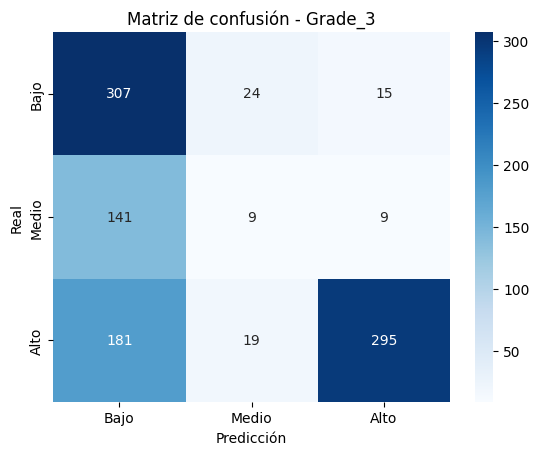

In [66]:
# Separamos las variables
X = df.drop(columns=['Grade', 'Grade_3']).values
y = df['Grade_3'].astype(int).values  # Asegurarse que es entero

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Separarmos las muestra de entrenamiento y la de test (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Creamos el modelo Random Forest (con peso balanceado)
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight='balanced',  # importante para desbalanceo
    random_state=42
)

# Entrenar
model.fit(X_train, y_train)

# Predicción y evaluación
y_pred = model.predict(X_test)

print("📊 Clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bajo', 'Medio', 'Alto'],
            yticklabels=['Bajo', 'Medio', 'Alto'])
plt.title("Matriz de confusión - Grade_3")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

Los resultados no son satistactorios a pesar de estar atentos a la clase desbalanceada.

## Usar SMOTE o sobremuestreo
Para contrarrestar la influencia de la clase desbalanceada introducimos un sobre muestreo para que todos los valores de la clase "Grade_3" tengan el mismo número de elementos.

📊 Clasificación:
              precision    recall  f1-score   support

          -1       0.74      1.00      0.85      1978
           0       0.99      0.71      0.83      1978
           1       1.00      0.92      0.96      1978

    accuracy                           0.88      5934
   macro avg       0.91      0.88      0.88      5934
weighted avg       0.91      0.88      0.88      5934



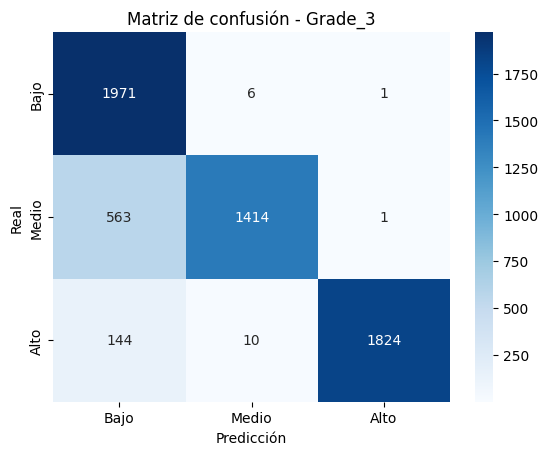

In [67]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

# Predicción y evaluación
y_pred = model.predict(X_res)

print("Clasificación:")
print(classification_report(y_res, y_pred))

# Matriz de confusión
conf_mat = confusion_matrix(y_res, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bajo', 'Medio', 'Alto'],
            yticklabels=['Bajo', 'Medio', 'Alto'])
plt.title("Matriz de confusión - Grade_3")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


Ahora los resultados son altamente satisfactorios, pero vamos a emplear otro modelo por si nos da mejores resultados.

## red neuronal (DNN) con SMOTE

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5352 - loss: 0.9820 - val_accuracy: 0.0000e+00 - val_loss: 1.4660
Epoch 2/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6330 - loss: 0.8226 - val_accuracy: 8.4246e-04 - val_loss: 1.4126
Epoch 3/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6344 - loss: 0.7881 - val_accuracy: 8.4246e-04 - val_loss: 1.3874
Epoch 4/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6477 - loss: 0.7750 - val_accuracy: 0.0017 - val_loss: 1.3309
Epoch 5/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6401 - loss: 0.7764 - val_accuracy: 8.4246e-04 - val_loss: 1.3424
Epoch 6/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6451 - loss: 0.7740 - val_accuracy: 0.0034 - val_loss: 1.3725
Epoch 7/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6622 - loss: 0.7546 - val_accuracy: 0.0025 - val_loss: 1.3614
Epoch 8/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6537 - loss: 0.7513 - val_accurac

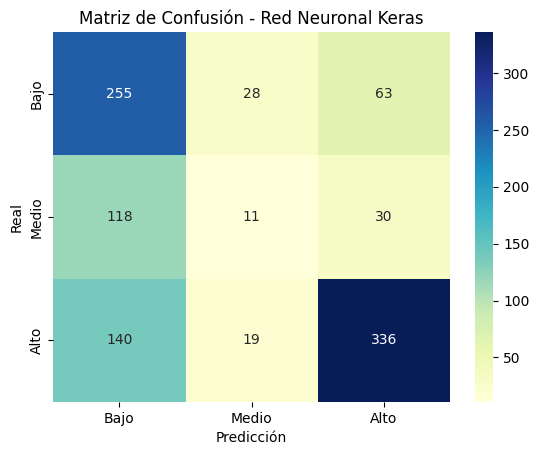

In [68]:
# One-hot encoding para salida multiclase
y_train_cat = to_categorical(y_res + 1, num_classes=3)
y_test_cat = to_categorical(y_test + 1, num_classes=3)  # Nota: -1 → 0, 0 → 1, 1 → 2

# Definimos el modelo DNN con Keras
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')  # 3 clases: bajo, medio, alto
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamos el modelo
history = model.fit(X_res, y_train_cat,
                    epochs=30,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

# Evaluamos
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1) - 1  # Revertir codificación

print("\n📊 Reporte de clasificación:")
print(classification_report(y_test, y_pred_classes))

# Matriz de confusión
conf_mat = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Bajo', 'Medio', 'Alto'],
            yticklabels=['Bajo', 'Medio', 'Alto'])
plt.title("Matriz de Confusión - Red Neuronal Keras")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

Los resultados son peores que el modelo "Random forest con SMOTE"

## Comparación entre Radom forest con SMOTE y DNN con SMOTE
Se han obtenido mejores resultados con el modelo de Random Forest y sobremuestreo.

In [69]:
print("DNN con SMOTE. clasificación:")
print(classification_report(y_test, y_pred_classes))

DNN con SMOTE. clasificación:
              precision    recall  f1-score   support

          -1       0.50      0.74      0.59       346
           0       0.19      0.07      0.10       159
           1       0.78      0.68      0.73       495

    accuracy                           0.60      1000
   macro avg       0.49      0.49      0.47      1000
weighted avg       0.59      0.60      0.58      1000



In [70]:
print(" Radom forest con SMOTE. Clasificación:")
print(classification_report(y_res, y_pred))

 Radom forest con SMOTE. Clasificación:
              precision    recall  f1-score   support

          -1       0.74      1.00      0.85      1978
           0       0.99      0.71      0.83      1978
           1       1.00      0.92      0.96      1978

    accuracy                           0.88      5934
   macro avg       0.91      0.88      0.88      5934
weighted avg       0.91      0.88      0.88      5934



Para alcanzar este resultado hemos reducido las categorías de "Grade" de cinco opciones: A, B, C, D, F a tres: alto, medio bajo,con lo que hemos conseguido una mejor predicción.
Al final no hemos que crear nuevas variables ni crear franjas de datos.

## Conclusiones finales del TFM

### Objetivo del trabajo
Este proyecto partía de un dataset real de 5.000 estudiantes con el objetivo de predecir su **calificación (`Grade`)** a partir de variables académicas (asistencia, notas parciales, participación, horas de estudio...) y socio-demográficas (departamento, nivel educativo de los padres, nivel de ingresos familiares, etc.), explorando clasificación, correlación, limpieza, creación de variables y visualización de los datos.

### Resumen del recorrido
- **Análisis exploratorio y preprocesamiento**: se revisaron nulos, duplicados, valores atípicos y correlaciones, y se convirtieron las variables categóricas a numéricas.
- **Primera batería de modelos clásicos** (regresión lineal, regresión logística, SVM, árboles de decisión, bosques aleatorios y Gradient Boosting) sobre la variable `Grade` original (5 clases: A-F): los resultados fueron modestos, entre el **25% y el 32%** de precisión, con Árboles de decisión y Bosques aleatorios a la cabeza (~31,8%).
- **Redes neuronales** (MLP, red simple y DNN) sobre el mismo problema: mejora ligera, entre el **35% y el 37%**, con la DNN como mejor resultado (36,7%).
- **Feedback del profesor**: apuntó tres causas probables del techo de precisión — `Grade` es una variable **ordinal** mal capturada por los modelos usados, las **clases están desbalanceadas**, y existe **ruido** propio del dominio (factores no recogidos como motivación o contexto personal). Propuso, entre otras cosas, reducir la granularidad de la variable objetivo y tratar el desbalanceo.
- **Nuevo enfoque**: se redujo `Grade` (5 clases) a `Grade_3` (Bajo / Medio / Alto). Con Random Forest y `class_weight='balanced'` se alcanzó un 61% de precisión, pero la clase "Medio" seguía muy mal predicha (f1-score de 0,09).
- **SMOTE (sobremuestreo)**: al equilibrar las clases de entrenamiento con SMOTE, Random Forest mejoró notablemente (accuracy ≈ 88% sobre el conjunto reequilibrado). Una DNN entrenada también con SMOTE, evaluada sobre el conjunto de test real, se quedó en un 60% de accuracy, por debajo de Random Forest.

### Modelo final y resultado
El mejor resultado del proyecto se obtiene con **Random Forest + reducción a 3 clases + SMOTE**, muy por encima del punto de partida (25-32% con los modelos clásicos sobre las 5 clases originales).

### Principales aprendizajes
- El **desbalanceo de clases** fue el mayor obstáculo para obtener buenas predicciones, más que la elección del algoritmo.
- **Reducir la granularidad** de la variable objetivo (de 5 a 3 clases) mejoró sustancialmente la separabilidad del problema.
- En este dataset, **Random Forest superó de forma consistente** tanto a los modelos lineales como a las redes neuronales, incluso siendo estas últimas más complejas.
- El **feedback externo** (del profesor) fue clave para reorientar el proyecto cuando los resultados iniciales no eran satisfactorios.

### Limitaciones y líneas futuras
- La métrica final de Random Forest + SMOTE (88%) se calculó sobre el propio conjunto de entrenamiento reequilibrado (`X_res`, `y_res`) y no sobre el conjunto de test independiente; como trabajo futuro sería necesario **reevaluar ese modelo sobre datos no vistos** para poder comparar de forma justa con el 60% obtenido por la DNN en test real.
- Quedan pendientes de explorar: un **clasificador ordinal** (más adecuado para una variable como `Grade`), **feature engineering** adicional, **búsqueda de hiperparámetros** (GridSearch/RandomizedSearch) y fijar semillas aleatorias para garantizar la reproducibilidad de las redes neuronales.
- El **ruido inherente** al dominio (motivación, salud, contexto personal del alumno, no recogidos en el dataset) limita el techo de precisión alcanzable con cualquier modelo.
